# Project 12. PDEBench: PDE Identification and Dynamic Prediction

This notebook is designed to run top-to-bottom on a regular local computer and produce the artifacts needed for the course project:

- parse PDEBench HDF5 data;
- visualize 1D PDE dynamics;
- predict dynamics with Dynamic Mode Decomposition (DMD);
- identify governing PDE terms with PDE-FIND / SINDy;
- train a lightweight neural baseline inspired by Fourier Neural Operator (FNO);
- compare all methods by accuracy and compute time;
- export tables and figures for the final presentation.

The main dataset is 1D Burgers with viscosity `nu=0.01`. The secondary dataset is 1D Advection with `beta=0.4`.

Put the `.hdf5` files into the project `data/` directory. If they are missing and internet access is available, the notebook can download them automatically.

## Grading checklist covered by this notebook

The project description asks for increasing levels of completeness:

| Requirement level | What this notebook does |
|---|---|
| 70% | Loads PDEBench data, preprocesses it, chooses manageable subsets, documents data shape and coordinates. |
| 80% | Applies data-driven algorithms and creates visualizations: heatmaps, time slices, prediction comparisons, error curves. |
| 90% | Computes metrics and compares DMD / PDE-FIND / neural baseline / naive persistence. |
| Advanced | Includes a compact machine-learning baseline inspired by FNO and interprets PDE-FIND coefficients against the known equations. |

Known governing forms used for interpretation:

- Advection: `u_t + beta u_x = 0`, so `u_t = - beta u_x`.
- Burgers: `u_t + u u_x = nu u_xx`, so `u_t = -u u_x + nu u_xx`.

For the final presentation, use the exported plots and tables from the project `results/` directory.

In [16]:
# Core imports and reproducibility
%matplotlib inline

import os
import time
import math
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests
except Exception:
    requests = None

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except Exception:
    torch = None
    nn = None
    DataLoader = None
    TensorDataset = None

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
WORK_DIR = PROJECT_ROOT
INPUT_DIR = PROJECT_ROOT
DATA_DIR = WORK_DIR / "data"
RESULTS_DIR = WORK_DIR / "results"
FIG_DIR = RESULTS_DIR / "figures"

for p in [DATA_DIR, RESULTS_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

device = "cuda" if (torch is not None and torch.cuda.is_available()) else "cpu"
print(f"Project root:      {PROJECT_ROOT}")
print(f"Data directory:    {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Compute device:    {device}")

Working directory: .
Input directory:   data
Compute device:    auto


## Configuration

The defaults are chosen for a regular laptop or desktop computer:

- use a downsampled spatial grid so DMD, PDE-FIND and the neural baseline run in reasonable time;
- train the neural baseline for a modest number of epochs;
- process Burgers as the main dataset and Advection as a secondary robustness check.

If the notebook runs too long, reduce `max_samples`, increase `stride_x`, or reduce `fno_epochs`.

In [17]:
CONFIG = {
    "datasets": [
        {
            "name": "Burgers_nu_0p01",
            "pde": "Burgers",
            "filename": "1D_Burgers_Sols_Nu0.01.hdf5",
            "url": "https://darus.uni-stuttgart.de/api/access/datafile/281363",
            "md5": "e6d9a4f62baf9a29121a816b919e2770",
            "expected": {"u*ux": -1.0, "uxx": 0.01},
            "enabled": True,
        },
        {
            "name": "Advection_beta_0p4",
            "pde": "Advection",
            "filename": "1D_Advection_Sols_beta0.4.hdf5",
            "url": "https://darus.uni-stuttgart.de/api/access/datafile/255674",
            "md5": "d595bbfd2c659df995a93cd40d6ea568",
            "expected": {"ux": -0.4},
            "enabled": True,
        },
    ],
    # Data reduction. Full PDEBench files are large; read slices directly from HDF5.
    "max_samples": 64,
    "stride_x": 4,
    "max_time_steps": None,
    "train_fraction": 0.65,
    # DMD
    "dmd_rank": 24,
    # PDE-FIND / SINDy
    "sindy_max_points": 220_000,
    "sindy_threshold": 0.025,
    "sindy_max_iter": 12,
    "pdefind_rollout_substeps": 2,
    # Neural baseline
    "train_fno_baseline": True,
    "fno_epochs": 20,
    "fno_batch_size": 64,
    "fno_learning_rate": 2e-3,
    "fno_modes": 16,
    "fno_width": 48,
    "fno_max_train_pairs": 12_000,
    # IO
    "download_if_missing": True,
    "verify_md5_after_download": False,
}

CONFIG

{'datasets': [{'name': 'Burgers_nu_0p01',
   'pde': 'Burgers',
   'filename': '1D_Burgers_Sols_Nu0.01.hdf5',
   'url': 'https://darus.uni-stuttgart.de/api/access/datafile/281363',
   'md5': 'e6d9a4f62baf9a29121a816b919e2770',
   'expected': {'u*ux': -1.0, 'uxx': 0.01},
   'enabled': True},
  {'name': 'Advection_beta_0p4',
   'pde': 'Advection',
   'filename': '1D_Advection_Sols_beta0.4.hdf5',
   'url': 'https://darus.uni-stuttgart.de/api/access/datafile/255674',
   'md5': 'd595bbfd2c659df995a93cd40d6ea568',
   'expected': {'ux': -0.4},
   'enabled': True}],
 'max_samples': 64,
 'stride_x': 4,
 'max_time_steps': None,
 'train_fraction': 0.65,
 'dmd_rank': 24,
 'sindy_max_points': 220000,
 'sindy_threshold': 0.025,
 'sindy_max_iter': 12,
 'pdefind_rollout_substeps': 2,
 'train_fno_baseline': True,
 'fno_epochs': 20,
 'fno_batch_size': 64,
 'fno_learning_rate': 0.002,
 'fno_modes': 16,
 'fno_width': 48,
 'fno_max_train_pairs': 12000,
 'download_if_missing': True,
 'verify_md5_after_downlo

## Data download and HDF5 loading

PDEBench stores these 1D datasets in HDF5 files. For Burgers and Advection, the important keys are:

- `tensor`: solution array, usually shaped like `(samples, time, x, channels)` or `(samples, time, x)`;
- `x-coordinate`: spatial grid;
- sometimes a time coordinate key such as `t-coordinate`, `t` or `time`.

The code below first searches the project `data/` directory and only downloads when needed.

In [18]:
def human_bytes(num: float) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    for unit in units:
        if num < 1024:
            return f"{num:.1f} {unit}"
        num /= 1024
    return f"{num:.1f} PB"


def find_existing_file(filename: str):
    candidates = []
    for root in [DATA_DIR, INPUT_DIR]:
        if root.exists():
            candidates.extend(root.rglob(filename))
    return candidates[0] if candidates else None


def compute_md5(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def download_file(url: str, dest: Path, expected_md5=None) -> Path:
    if requests is None:
        raise RuntimeError("requests is unavailable. Put the HDF5 file into the project data directory instead.")

    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    print(f"Downloading {url}")
    print(f"Destination: {dest}")
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", "0"))
        downloaded = 0
        last_report = 0
        with tmp.open("wb") as f:
            for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
                if not chunk:
                    continue
                f.write(chunk)
                downloaded += len(chunk)
                if downloaded - last_report > 512 * 1024 * 1024:
                    last_report = downloaded
                    if total:
                        print(f"  {human_bytes(downloaded)} / {human_bytes(total)}")
                    else:
                        print(f"  {human_bytes(downloaded)}")
    tmp.rename(dest)

    if CONFIG["verify_md5_after_download"] and expected_md5:
        got = compute_md5(dest)
        if got != expected_md5:
            raise RuntimeError(f"MD5 mismatch for {dest.name}: expected {expected_md5}, got {got}")
    return dest


def ensure_dataset_file(spec: dict) -> Path:
    existing = find_existing_file(spec["filename"])
    if existing is not None:
        print(f"Found existing file: {existing} ({human_bytes(existing.stat().st_size)})")
        return existing

    if not CONFIG["download_if_missing"]:
        raise FileNotFoundError(f"{spec['filename']} not found in {INPUT_DIR} or {DATA_DIR}")

    return download_file(spec["url"], DATA_DIR / spec["filename"], spec.get("md5"))


def inspect_h5(path: Path) -> dict:
    with h5py.File(path, "r") as f:
        info = {}
        for k in f.keys():
            obj = f[k]
            if hasattr(obj, "shape"):
                info[k] = {"shape": tuple(obj.shape), "dtype": str(obj.dtype)}
            else:
                info[k] = {"type": type(obj).__name__}
        return info


def read_time_coordinate(f: h5py.File, n_time: int) -> np.ndarray:
    for key in ["t-coordinate", "t_coordinates", "time", "t"]:
        if key in f and hasattr(f[key], "shape"):
            arr = np.asarray(f[key][:], dtype=np.float64).reshape(-1)
            if len(arr) >= n_time:
                return arr[:n_time]
    return np.linspace(0.0, 1.0, n_time)


def load_pdebench_1d(
    path,
    max_samples=None,
    stride_x=1,
    max_time_steps=None,
):
    with h5py.File(path, "r") as f:
        tensor = f["tensor"]
        shape_original = tensor.shape

        x = np.asarray(f["x-coordinate"], dtype=np.float32)
        t = np.asarray(f["t-coordinate"], dtype=np.float32)

        sample_slice = slice(None if max_samples is None else max_samples)
        time_slice = slice(None if max_time_steps is None else max_time_steps)
        x_slice = slice(None, None, stride_x)

        if tensor.ndim == 4:
            # Expected format:
            # samples x time x x x channels
            data = tensor[sample_slice, time_slice, x_slice, 0]

        elif tensor.ndim == 3:
            # Actual format in your files:
            # samples x time x x
            data = tensor[sample_slice, time_slice, x_slice]

        else:
            raise ValueError(
                f"Expected 3D or 4D tensor, got {tensor.shape}"
            )

        data = np.asarray(data, dtype=np.float32)
        x = x[::stride_x]

        if max_time_steps is not None:
            t = t[:max_time_steps]

    return {
        "data": data,
        "u": data,
        "x": x,
        "t": t,
        "shape_original": shape_original,
        "shape_loaded": data.shape,
        "path": str(path),
    }

In [19]:
loaded: Dict[str, dict] = {}

for spec in CONFIG["datasets"]:
    if not spec["enabled"]:
        continue
    print("\n" + "=" * 90)
    print(f"Dataset: {spec['name']} ({spec['pde']})")
    try:
        path = ensure_dataset_file(spec)
        print("HDF5 keys and shapes:")
        display(pd.DataFrame(inspect_h5(path)).T)
        ds = load_pdebench_1d(
            path,
            max_samples=CONFIG["max_samples"],
            stride_x=CONFIG["stride_x"],
            max_time_steps=CONFIG["max_time_steps"],
        )
        ds["spec"] = spec
        loaded[spec["name"]] = ds
        print(f"Original tensor shape: {ds['shape_original']}")
        print(f"Loaded subset shape:   {ds['shape_loaded']} = samples x time x x")
        print(f"x range: {ds['x'][0]:.4g} .. {ds['x'][-1]:.4g}, points={len(ds['x'])}")
        print(f"t range: {ds['t'][0]:.4g} .. {ds['t'][-1]:.4g}, steps={len(ds['t'])}")
    except Exception as e:
        print(f"Skipping {spec['name']} because of error: {type(e).__name__}: {e}")

if not loaded:
    raise RuntimeError("No datasets loaded. Enable internet access or put the HDF5 files into the project data directory.")

list(loaded.keys())


Dataset: Burgers_nu_0p01 (Burgers)
Found existing file: data/1D_Burgers_Sols_Nu0.01.hdf5 (7.7 GB)
HDF5 keys and shapes:


,shape,dtype
t-coordinate,"(202,)",float32
tensor,"(10000, 201, 1024)",float32
x-coordinate,"(1024,)",float32


Original tensor shape: (10000, 201, 1024)
Loaded subset shape:   (64, 201, 256) = samples x time x x
x range: 0.0004883 .. 0.9966, points=256
t range: 0 .. 2.01, steps=202

Dataset: Advection_beta_0p4 (Advection)
Found existing file: data/1D_Advection_Sols_beta0.4.hdf5 (7.7 GB)
HDF5 keys and shapes:


,shape,dtype
t-coordinate,"(202,)",float32
tensor,"(10000, 201, 1024)",float32
x-coordinate,"(1024,)",float32


Original tensor shape: (10000, 201, 1024)
Loaded subset shape:   (64, 201, 256) = samples x time x x
x range: 0.0004883 .. 0.9966, points=256
t range: 0 .. 2.01, steps=202


['Burgers_nu_0p01', 'Advection_beta_0p4']

## Exploratory visualization

For each loaded dataset we plot:

- a heatmap of `u(x,t)` for one trajectory;
- several time slices `u(x)` to see wave propagation, diffusion, shocks or numerical smoothing.

These figures are useful directly in the final presentation because they explain what the algorithms are trying to model.

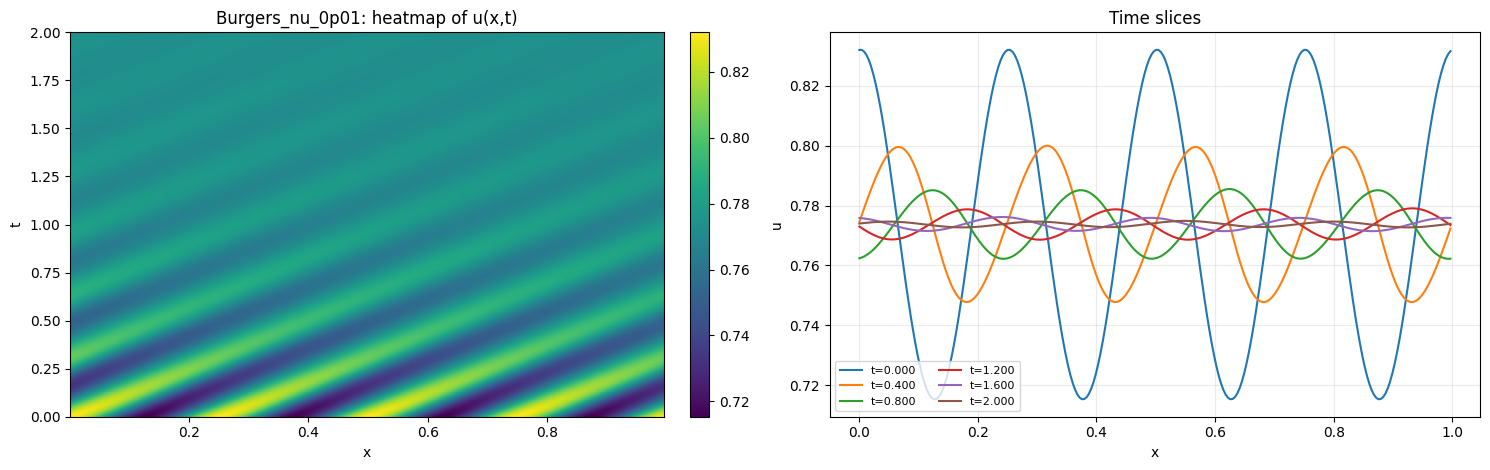

Saved: results/figures/Burgers_nu_0p01_overview.png


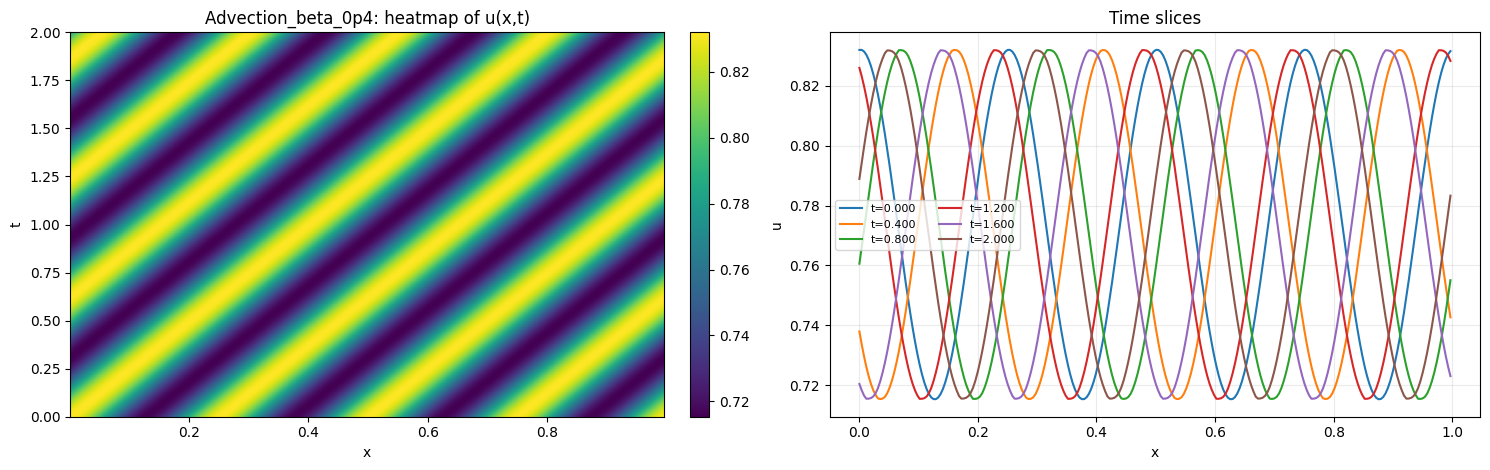

Saved: results/figures/Advection_beta_0p4_overview.png


In [20]:
def plot_dataset_overview(name: str, ds: dict, sample: int = 0):
    data = ds["data"]
    x, t = ds["x"], ds["t"]
    u = data[sample]

    t = t[:u.shape[0]]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    im = axes[0].imshow(
        u,
        aspect="auto",
        origin="lower",
        extent=[x[0], x[-1], t[0], t[-1]],
        cmap="viridis",
    )
    axes[0].set_title(f"{name}: heatmap of u(x,t)")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("t")
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    time_ids = np.linspace(0, u.shape[0] - 1, 6, dtype=int)

    for tid in time_ids:
        axes[1].plot(x, u[tid], label=f"t={t[tid]:.3f}")

    axes[1].set_title("Time slices")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].legend(ncol=2, fontsize=8)
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    out = FIG_DIR / f"{name}_overview.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


for name, ds in loaded.items():
    plot_dataset_overview(name, ds, sample=0)

## Metrics

We evaluate all prediction methods on the held-out future time interval.

Metrics:

- `RMSE`: standard root mean squared error;
- `nRMSE`: RMSE normalized by signal RMS;
- `max_error`: worst absolute error;
- `boundary_RMSE`: error at the left/right boundaries;
- `conserved_RMSE`: error in spatial integral, useful for PDE consistency;
- Fourier-band errors: low, mid and high spatial frequencies.

This mirrors the spirit of PDEBench metrics while staying compact enough for one notebook.

In [21]:
def split_train_test(data: np.ndarray, train_fraction: float) -> int:
    n_time = data.shape[1]
    n_train = int(round(n_time * train_fraction))
    return max(4, min(n_train, n_time - 2))


def spatial_integral(u: np.ndarray, x: np.ndarray) -> np.ndarray:
    return np.trapz(u, x=x, axis=-1)


def fourier_band_rmse(pred: np.ndarray, true: np.ndarray) -> dict:
    err_hat = np.fft.rfft(pred - true, axis=-1)
    true_hat = np.fft.rfft(true, axis=-1)
    n_freq = err_hat.shape[-1]
    edges = [0, max(1, n_freq // 4), max(2, n_freq // 2), n_freq]
    names = ["fourier_low", "fourier_mid", "fourier_high"]
    out = {}
    for label, a, b in zip(names, edges[:-1], edges[1:]):
        num = np.sqrt(np.mean(np.abs(err_hat[..., a:b]) ** 2))
        den = np.sqrt(np.mean(np.abs(true_hat[..., a:b]) ** 2)) + 1e-12
        out[label] = float(num / den)
    return out


def evaluate_prediction(pred: np.ndarray, true: np.ndarray, x: np.ndarray) -> dict:
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)

    err = pred - true
    rmse = float(np.sqrt(np.mean(err**2)))
    mae = float(np.mean(np.abs(err)))
    mape_eps = float(100.0 * np.mean(np.abs(err) / (np.abs(true) + 1e-6)))
    signal = float(np.sqrt(np.mean(true**2))) + 1e-12
    boundary_err = err[..., [0, -1]]
    conserved_err = spatial_integral(pred, x) - spatial_integral(true, x)

    metrics = {
        "RMSE": rmse,
        "nRMSE": rmse / signal,
        "MAE": mae,
        "MAPE_eps": mape_eps,
        "max_error": float(np.max(np.abs(err))),
        "boundary_RMSE": float(np.sqrt(np.mean(boundary_err**2))),
        "conserved_RMSE": float(np.sqrt(np.mean(conserved_err**2))),
    }
    metrics.update(fourier_band_rmse(pred, true))
    return metrics


def persistence_forecast(data: np.ndarray, n_train: int) -> np.ndarray:
    steps = data.shape[1] - n_train
    last = data[:, n_train - 1 : n_train, :]
    return np.repeat(last, steps, axis=1)

## Method 1: Dynamic Mode Decomposition

DMD approximates a linear evolution operator:

`u_{k+1} ≈ A u_k`.

Even for nonlinear PDEs, DMD is a strong baseline because it finds coherent spatiotemporal modes by SVD and extrapolates them in time. Here we fit one ensemble DMD operator per dataset using all training trajectories.

In [22]:
def fit_dmd_ensemble(data_train: np.ndarray, dt: float, rank: int = 24) -> dict:
    # data_train: samples x time x x
    X = np.concatenate([traj[:-1].T for traj in data_train], axis=1)
    Y = np.concatenate([traj[1:].T for traj in data_train], axis=1)

    U, S, Vh = np.linalg.svd(X, full_matrices=False)
    r = int(min(rank, np.sum(S > 1e-12), U.shape[1]))
    U_r = U[:, :r]
    S_r = S[:r]
    V_r = Vh.conj().T[:, :r]

    A_tilde = U_r.conj().T @ Y @ V_r @ np.diag(1.0 / S_r)
    eigvals, W = np.linalg.eig(A_tilde)
    Phi = Y @ V_r @ np.diag(1.0 / S_r) @ W
    omega = np.log(eigvals + 1e-14) / dt

    return {"Phi": Phi, "eigvals": eigvals, "omega": omega, "rank": r, "dt": dt}


def dmd_forecast(model: dict, initial_states: np.ndarray, steps: int) -> np.ndarray:
    Phi = model["Phi"]
    omega = model["omega"]
    dt = model["dt"]
    times = np.arange(1, steps + 1) * dt

    preds = np.empty((initial_states.shape[0], steps, initial_states.shape[1]), dtype=np.float64)
    for i, u0 in enumerate(initial_states):
        b, *_ = np.linalg.lstsq(Phi, u0, rcond=None)
        dynamics = np.exp(np.outer(omega, times)) * b[:, None]
        pred = (Phi @ dynamics).T.real
        preds[i] = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    return preds


dmd_results = {}

for name, ds in loaded.items():
    data, t = ds["data"], ds["t"]
    n_train = split_train_test(data, CONFIG["train_fraction"])
    dt = float(np.median(np.diff(t)))

    print(
        f"\nDMD: {name}, "
        f"train steps={n_train}, "
        f"test steps={data.shape[1] - n_train}, "
        f"dt={dt:.4g}"
    )

    # --- Training / fitting time ---
    train_start = time.perf_counter()
    model = fit_dmd_ensemble(
        data[:, :n_train, :],
        dt=dt,
        rank=CONFIG["dmd_rank"]
    )
    train_seconds = time.perf_counter() - train_start

    # --- Prediction / forecast time ---
    pred_start = time.perf_counter()
    pred = dmd_forecast(
        model,
        data[:, n_train - 1, :],
        steps=data.shape[1] - n_train
    )
    prediction_seconds = time.perf_counter() - pred_start

    elapsed = train_seconds + prediction_seconds

    dmd_results[name] = {
        "model": model,
        "pred": pred,
        "seconds": elapsed,
        "train_seconds": train_seconds,
        "prediction_seconds": prediction_seconds,
        "n_train": n_train,
    }

    print(
        f"  rank={model['rank']}, "
        f"train={train_seconds:.2f}s, "
        f"prediction={prediction_seconds:.2f}s, "
        f"total={elapsed:.2f}s"
    )


DMD: Burgers_nu_0p01, train steps=131, test steps=70, dt=0.01
  rank=24, train=0.38s, prediction=0.08s, total=0.46s

DMD: Advection_beta_0p4, train steps=131, test steps=70, dt=0.01
  rank=24, train=0.39s, prediction=0.08s, total=0.48s


## Method 2: PDE-FIND / SINDy for PDE identification

SINDy identifies sparse dynamics from a library of candidate terms. For PDEs this is often called PDE-FIND.

We fit a sparse regression model:

`u_t = c0 + c1 u + c2 u^2 + c3 u^3 + c4 u_x + c5 u_xx + c6 u_xxx + c7 u u_x + c8 u u_xx + c9 u^2 u_x`

Expected result:

- Burgers: large terms should be approximately `u u_x` and `u_xx`;
- Advection: large term should be approximately `u_x`.

The exact coefficients can be imperfect because we use finite differences on a downsampled grid. The important advanced-project point is that the identified sparse structure should match the governing equation.

In [23]:
TERM_NAMES = ["1", "u", "u^2", "u^3", "ux", "uxx", "uxxx", "u*ux", "u*uxx", "u^2*ux"]


def derivatives_batch(data: np.ndarray, x: np.ndarray, t: np.ndarray) -> dict:
    dx = float(np.median(np.diff(x)))
    dt = float(np.median(np.diff(t)))
    u = data
    ut = np.gradient(u, dt, axis=1, edge_order=2)
    ux = np.gradient(u, dx, axis=2, edge_order=2)
    uxx = np.gradient(ux, dx, axis=2, edge_order=2)
    uxxx = np.gradient(uxx, dx, axis=2, edge_order=2)
    return {"u": u, "ut": ut, "ux": ux, "uxx": uxx, "uxxx": uxxx, "dx": dx, "dt": dt}


def build_library_from_derivatives(d: dict, trim_t: int = 2, trim_x: int = 3) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    sl = (slice(None), slice(trim_t, -trim_t), slice(trim_x, -trim_x))
    u = d["u"][sl].reshape(-1)
    ux = d["ux"][sl].reshape(-1)
    uxx = d["uxx"][sl].reshape(-1)
    uxxx = d["uxxx"][sl].reshape(-1)
    y = d["ut"][sl].reshape(-1)

    Theta = np.column_stack([
        np.ones_like(u),
        u,
        u**2,
        u**3,
        ux,
        uxx,
        uxxx,
        u * ux,
        u * uxx,
        (u**2) * ux,
    ])
    mask = np.isfinite(y) & np.all(np.isfinite(Theta), axis=1)
    return Theta[mask], y[mask], TERM_NAMES


def subsample_rows(Theta: np.ndarray, y: np.ndarray, max_points: int, seed: int = 42):
    if len(y) <= max_points:
        return Theta, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(y), size=max_points, replace=False)
    return Theta[idx], y[idx]


def stlsq(Theta: np.ndarray, y: np.ndarray, threshold: float = 0.025, max_iter: int = 12) -> np.ndarray:
    # Sequential thresholded least squares with column normalization.
    scale = np.linalg.norm(Theta, axis=0)
    scale[scale == 0] = 1.0
    X = Theta / scale

    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    for _ in range(max_iter):
        small = np.abs(coef) < threshold
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef_big, *_ = np.linalg.lstsq(X[:, big], y, rcond=None)
        coef[big] = coef_big
    return coef / scale


def fit_pdefind(data_train: np.ndarray, x: np.ndarray, t: np.ndarray) -> dict:
    d = derivatives_batch(data_train, x, t[: data_train.shape[1]])
    Theta, y, names = build_library_from_derivatives(d)
    Theta, y = subsample_rows(Theta, y, CONFIG["sindy_max_points"], seed=SEED)
    coef = stlsq(
        Theta,
        y,
        threshold=CONFIG["sindy_threshold"],
        max_iter=CONFIG["sindy_max_iter"],
    )
    y_pred = Theta @ coef
    derivative_rmse = float(np.sqrt(np.mean((y_pred - y) ** 2)))
    return {"coef": coef, "terms": names, "derivative_rmse": derivative_rmse}


def rhs_from_terms(u: np.ndarray, x: np.ndarray, coef: np.ndarray, names: List[str]) -> np.ndarray:
    dx = float(np.median(np.diff(x)))
    ux = np.gradient(u, dx, edge_order=2)
    uxx = np.gradient(ux, dx, edge_order=2)
    uxxx = np.gradient(uxx, dx, edge_order=2)
    values = {
        "1": np.ones_like(u),
        "u": u,
        "u^2": u**2,
        "u^3": u**3,
        "ux": ux,
        "uxx": uxx,
        "uxxx": uxxx,
        "u*ux": u * ux,
        "u*uxx": u * uxx,
        "u^2*ux": (u**2) * ux,
    }
    rhs = np.zeros_like(u, dtype=np.float64)
    for c, name in zip(coef, names):
        if abs(c) > 0:
            rhs += c * values[name]
    return rhs


def pdefind_rollout(model: dict, initial_states: np.ndarray, x: np.ndarray, dt: float, steps: int, clip_bounds: Tuple[float, float]) -> np.ndarray:
    substeps = max(1, int(CONFIG["pdefind_rollout_substeps"]))
    h = dt / substeps
    lo, hi = clip_bounds
    preds = np.empty((initial_states.shape[0], steps, initial_states.shape[1]), dtype=np.float64)
    for i, u0 in enumerate(initial_states):
        u = u0.astype(np.float64).copy()
        for k in range(steps):
            for _ in range(substeps):
                rhs = rhs_from_terms(u, x, model["coef"], model["terms"])
                u = u + h * rhs
                u = np.nan_to_num(u, nan=0.0, posinf=hi, neginf=lo)
                u = np.clip(u, lo, hi)
            preds[i, k] = u
    return preds


pdefind_results = {}

for name, ds in loaded.items():
    data, x, t = ds["data"], ds["x"], ds["t"]
    n_train = split_train_test(data, CONFIG["train_fraction"])
    dt = float(np.median(np.diff(t)))

    print(f"\nPDE-FIND: {name}")

    # --- Training / identification time ---
    train_start = time.perf_counter()
    model = fit_pdefind(data[:, :n_train, :], x, t)
    train_seconds = time.perf_counter() - train_start

    # Bounds are estimated from the training part only.
    lo, hi = np.percentile(data[:, :n_train, :], [0.1, 99.9])
    margin = 0.25 * (hi - lo)

    # --- Prediction / rollout time ---
    pred_start = time.perf_counter()
    pred = pdefind_rollout(
        model,
        data[:, n_train - 1, :],
        x=x,
        dt=dt,
        steps=data.shape[1] - n_train,
        clip_bounds=(float(lo - margin), float(hi + margin)),
    )
    prediction_seconds = time.perf_counter() - pred_start

    elapsed = train_seconds + prediction_seconds

    pdefind_results[name] = {
        "model": model,
        "pred": pred,
        "seconds": elapsed,
        "train_seconds": train_seconds,
        "prediction_seconds": prediction_seconds,
        "n_train": n_train,
    }

    coef_table = pd.DataFrame({
        "term": model["terms"],
        "coefficient": model["coef"],
    })
    coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
    display(coef_table.sort_values("abs_coefficient", ascending=False))

    print(
        f"Derivative fit RMSE: {model['derivative_rmse']:.4e}; "
        f"train={train_seconds:.2f}s, "
        f"prediction={prediction_seconds:.2f}s, "
        f"total={elapsed:.2f}s"
    )


PDE-FIND: Burgers_nu_0p01


,term,coefficient,abs_coefficient
7,u*ux,-0.928976,0.928976
3,u^3,0.109495,0.109495
1,u,-0.079721,0.079721
2,u^2,0.047363,0.047363
9,u^2*ux,-0.027063,0.027063
0,1,-0.009438,0.009438
4,ux,0.008237,0.008237
5,uxx,0.003553,0.003553
8,u*uxx,0.000359,0.000359
6,uxxx,0.000001,0.000001


Derivative fit RMSE: 4.5486e-01; train=1.15s, prediction=1.88s, total=3.03s

PDE-FIND: Advection_beta_0p4


,term,coefficient,abs_coefficient
4,ux,-4.000474e-01,4.000474e-01
1,u,1.042559e-04,1.042559e-04
2,u^2,-9.023788e-05,9.023788e-05
3,u^3,-4.473799e-05,4.473799e-05
9,u^2*ux,1.141197e-05,1.141197e-05
7,u*ux,-8.927555e-06,8.927555e-06
8,u*uxx,-3.465176e-07,3.465176e-07
5,uxx,3.166041e-07,3.166041e-07
6,uxxx,-4.691146e-08,4.691146e-08
0,1,0.000000e+00,0.000000e+00


Derivative fit RMSE: 3.0496e-03; train=1.07s, prediction=1.89s, total=2.96s


## Method 3: Lightweight neural baseline, compact FNO-style model

The official PDEBench repository uses FNO, U-Net and PINN baselines. Full official training can be heavy, so this notebook implements a compact Fourier Neural Operator style baseline that is practical on a regular computer:

- spectral convolution in Fourier space;
- autoregressive one-step training `u_t -> u_{t+1}`;
- rollout over the held-out future interval.

This provides a real machine-learning baseline for the Advanced requirement while keeping the notebook reproducible and lightweight.


FNO-style neural baseline: Burgers_nu_0p01, device=auto
  epoch 001/20: MSE=8.00474e-02
  epoch 005/20: MSE=6.34889e-05
  epoch 010/20: MSE=5.76034e-05
  epoch 015/20: MSE=8.79143e-04
  epoch 020/20: MSE=3.41862e-05


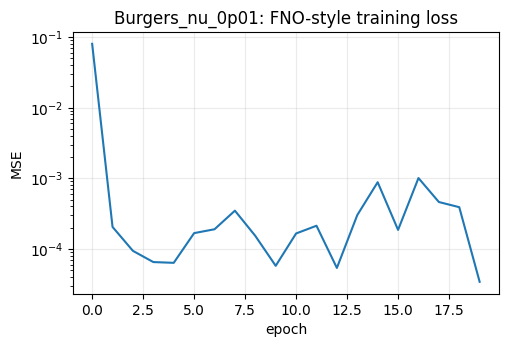

Saved: results/figures/Burgers_nu_0p01_fno_loss.png; train=18.51s; prediction=0.16s; total=18.67s

FNO-style neural baseline: Advection_beta_0p4, device=auto
  epoch 001/20: MSE=6.65063e-02
  epoch 005/20: MSE=1.08334e-04
  epoch 010/20: MSE=2.27604e-05
  epoch 015/20: MSE=1.38941e-04
  epoch 020/20: MSE=2.11244e-04


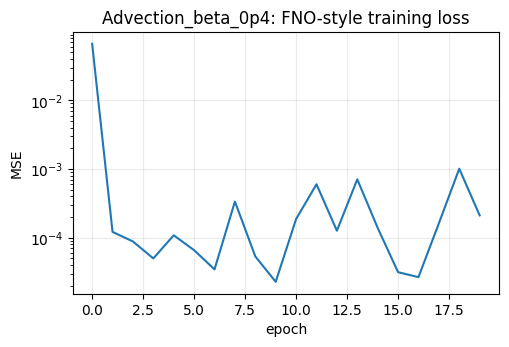

Saved: results/figures/Advection_beta_0p4_fno_loss.png; train=18.35s; prediction=0.16s; total=18.51s


In [24]:
if torch is not None:
    class SpectralConv1d(nn.Module):
        def __init__(self, in_channels, out_channels, modes):
            super().__init__()
            self.in_channels = in_channels
            self.out_channels = out_channels
            self.modes = modes
            scale = 1 / (in_channels * out_channels)
            self.weights = nn.Parameter(
                scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
            )

        def compl_mul1d(self, input, weights):
            return torch.einsum("bix,iox->box", input, weights)

        def forward(self, x):
            batchsize = x.shape[0]
            x_ft = torch.fft.rfft(x)
            out_ft = torch.zeros(
                batchsize,
                self.out_channels,
                x.size(-1) // 2 + 1,
                dtype=torch.cfloat,
                device=x.device,
            )
            m = min(self.modes, x_ft.shape[-1])
            out_ft[:, :, :m] = self.compl_mul1d(x_ft[:, :, :m], self.weights[:, :, :m])
            return torch.fft.irfft(out_ft, n=x.size(-1))


    class FNO1d(nn.Module):
        def __init__(self, modes=16, width=48):
            super().__init__()
            self.modes = modes
            self.width = width
            self.fc0 = nn.Linear(2, width)
            self.convs = nn.ModuleList([SpectralConv1d(width, width, modes) for _ in range(4)])
            self.ws = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(4)])
            self.fc1 = nn.Linear(width, 96)
            self.fc2 = nn.Linear(96, 1)
            self.act = nn.GELU()

        def forward(self, u):
            # u: batch x x x 1
            b, n, _ = u.shape
            grid = torch.linspace(0, 1, n, device=u.device).view(1, n, 1).repeat(b, 1, 1)
            x = torch.cat([u, grid], dim=-1)
            x = self.fc0(x).permute(0, 2, 1)
            for conv, w in zip(self.convs, self.ws):
                x = self.act(conv(x) + w(x))
            x = x.permute(0, 2, 1)
            x = self.act(self.fc1(x))
            x = self.fc2(x)
            return x


def make_one_step_pairs(data: np.ndarray, n_train: int, max_pairs: int) -> Tuple[np.ndarray, np.ndarray]:
    X = data[:, : n_train - 1, :].reshape(-1, data.shape[-1])
    Y = data[:, 1:n_train, :].reshape(-1, data.shape[-1])
    if len(X) > max_pairs:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(X), max_pairs, replace=False)
        X, Y = X[idx], Y[idx]
    return X.astype(np.float32), Y.astype(np.float32)


def train_fno_baseline(data: np.ndarray, n_train: int) -> dict:
    if torch is None:
        raise RuntimeError("PyTorch is unavailable")

    train_values = data[:, :n_train, :]
    mean = float(train_values.mean())
    std = float(train_values.std() + 1e-6)
    norm_data = (data - mean) / std

    X, Y = make_one_step_pairs(norm_data, n_train, CONFIG["fno_max_train_pairs"])
    X_t = torch.tensor(X[:, :, None])
    Y_t = torch.tensor(Y[:, :, None])
    loader = DataLoader(
        TensorDataset(X_t, Y_t),
        batch_size=CONFIG["fno_batch_size"],
        shuffle=True,
        drop_last=False,
    )

    model = FNO1d(modes=CONFIG["fno_modes"], width=CONFIG["fno_width"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["fno_learning_rate"], weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    history = []
    start = time.perf_counter()
    for epoch in range(1, CONFIG["fno_epochs"] + 1):
        model.train()
        total = 0.0
        count = 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            total += float(loss.detach().cpu()) * xb.shape[0]
            count += xb.shape[0]
        avg = total / max(1, count)
        history.append(avg)
        if epoch == 1 or epoch % 5 == 0 or epoch == CONFIG["fno_epochs"]:
            print(f"  epoch {epoch:03d}/{CONFIG['fno_epochs']}: MSE={avg:.5e}")

    seconds = time.perf_counter() - start
    return {
    "model": model,
    "mean": mean,
    "std": std,
    "history": history,
    "train_seconds": seconds,
}


@torch.no_grad()
def fno_rollout(fit: dict, initial_states: np.ndarray, steps: int) -> np.ndarray:
    model = fit["model"]
    mean, std = fit["mean"], fit["std"]
    model.eval()

    u = ((initial_states - mean) / std).astype(np.float32)
    preds = []
    for _ in range(steps):
        xb = torch.tensor(u[:, :, None], dtype=torch.float32, device=device)
        next_u = model(xb).squeeze(-1).detach().cpu().numpy()
        preds.append(next_u.copy())
        u = next_u
    pred_norm = np.stack(preds, axis=1)
    return pred_norm * std + mean


fno_results = {}

if CONFIG["train_fno_baseline"] and torch is not None:
    for name, ds in loaded.items():
        data = ds["data"]
        n_train = split_train_test(data, CONFIG["train_fraction"])
        print(f"\nFNO-style neural baseline: {name}, device={device}")
        fit = train_fno_baseline(data, n_train)
        pred_start = time.perf_counter()
        pred = fno_rollout(fit, data[:, n_train - 1, :], data.shape[1] - n_train)
        prediction_seconds = time.perf_counter() - pred_start
        fit["pred"] = pred
        fit["prediction_seconds"] = prediction_seconds
        fit["seconds"] = fit["train_seconds"] + prediction_seconds
        fit["n_train"] = n_train
        fno_results[name] = fit

        plt.figure(figsize=(5.5, 3.4))
        plt.plot(fit["history"])
        plt.yscale("log")
        plt.title(f"{name}: FNO-style training loss")
        plt.xlabel("epoch")
        plt.ylabel("MSE")
        plt.grid(alpha=0.25)
        out = FIG_DIR / f"{name}_fno_loss.png"
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print(
            f"Saved: {out}; "
            f"train={fit['train_seconds']:.2f}s; "
            f"prediction={fit['prediction_seconds']:.2f}s; "
            f"total={fit['seconds']:.2f}s"
        )
else:
    print("Skipping neural baseline because PyTorch is unavailable or disabled.")

## Quantitative comparison

All models are evaluated on the same test interval:

- `Persistence`: repeats the last training state. This is a simple baseline.
- `DMD`: data-driven linear modal forecast.
- `PDE-FIND/SINDy`: sparse identified PDE, rolled forward explicitly.
- `FNO-style`: neural machine-learning baseline trained on the same subset.

For the final report, the most important columns are `nRMSE`, `RMSE`, `max_error`, `conserved_RMSE` and `seconds`.

In [25]:
all_rows = []

for name, ds in loaded.items():
    data, x = ds["data"], ds["x"]
    n_train = split_train_test(data, CONFIG["train_fraction"])
    true = data[:, n_train:, :]

    methods = {
        "Persistence": {
            "pred": persistence_forecast(data, n_train),
            "train_seconds": 0.0,
            "prediction_seconds": 0.0,
            "seconds": 0.0,
        },
    }

    if name in dmd_results:
        methods["DMD"] = {
            "pred": dmd_results[name]["pred"],
            "train_seconds": dmd_results[name].get("train_seconds", np.nan),
            "prediction_seconds": dmd_results[name].get("prediction_seconds", np.nan),
            "seconds": dmd_results[name]["seconds"],
        }

    if name in pdefind_results:
        methods["PDE-FIND/SINDy"] = {
            "pred": pdefind_results[name]["pred"],
            "train_seconds": pdefind_results[name].get("train_seconds", np.nan),
            "prediction_seconds": pdefind_results[name].get("prediction_seconds", np.nan),
            "seconds": pdefind_results[name]["seconds"],
        }

    if name in fno_results:
        methods["FNO-style ML"] = {
            "pred": fno_results[name]["pred"],
            "train_seconds": fno_results[name].get("train_seconds", np.nan),
            "prediction_seconds": fno_results[name].get("prediction_seconds", np.nan),
            "seconds": fno_results[name]["seconds"],
        }

    for method, obj in methods.items():
        metrics = evaluate_prediction(obj["pred"], true, x)
        row = {
            "dataset": name,
            "pde": ds["spec"]["pde"],
            "method": method,
            "train_seconds": obj["train_seconds"],
            "prediction_seconds": obj["prediction_seconds"],
            "total_seconds": obj["seconds"],
            **metrics,
        }
        all_rows.append(row)

metrics_df = pd.DataFrame(all_rows)
metrics_df = metrics_df.sort_values(["dataset", "MAE"]).reset_index(drop=True)
display(metrics_df)

metrics_path = RESULTS_DIR / "metrics_table.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved metrics table: {metrics_path}")

,dataset,pde,method,train_seconds,prediction_seconds,total_seconds,RMSE,nRMSE,MAE,MAPE_eps,max_error,boundary_RMSE,conserved_RMSE,fourier_low,fourier_mid,fourier_high
0,Advection_beta_0p4,Advection,DMD,0.393660,0.083092,0.476752,0.021106,0.030029,0.006632,1.576315e+05,0.550026,0.010387,0.000042,0.023707,1.000880,1.000033e+00
1,Advection_beta_0p4,Advection,FNO-style ML,18.350552,0.159864,18.510416,0.573843,0.816466,0.261692,1.451790e+06,24.916783,0.585650,0.221268,0.697358,15.862854,1.710509e+01
2,Advection_beta_0p4,Advection,Persistence,0.000000,0.000000,0.000000,0.654168,0.930754,0.451053,9.279989e+05,3.142125,0.701947,0.002739,0.744126,1.375471,1.278674e+00
3,Advection_beta_0p4,Advection,PDE-FIND/SINDy,1.069454,1.887901,2.957354,1.653924,2.353211,1.020656,5.305370e+06,5.564950,1.751520,0.329526,0.704789,399.712936,9.313073e+02
4,Burgers_nu_0p01,Burgers,FNO-style ML,18.506672,0.162197,18.668869,0.059344,0.111087,0.037098,4.002984e+01,0.569732,0.052686,0.055524,0.108368,2.040052,5.221740e+02
5,Burgers_nu_0p01,Burgers,DMD,0.380905,0.082707,0.463612,0.073658,0.137882,0.045793,8.356305e+01,0.544620,0.068037,0.000272,0.098058,2.900188,9.952884e+01
6,Burgers_nu_0p01,Burgers,Persistence,0.000000,0.000000,0.000000,0.090953,0.170256,0.051812,2.360125e+01,0.641555,0.077946,0.000313,0.121082,2.600543,3.150808e+00
7,Burgers_nu_0p01,Burgers,PDE-FIND/SINDy,1.154657,1.880141,3.034798,0.391461,0.732783,0.082924,1.688609e+01,3.745124,0.565091,0.204349,0.430053,2176.338030,2.254739e+06


Saved metrics table: results/metrics_table.csv


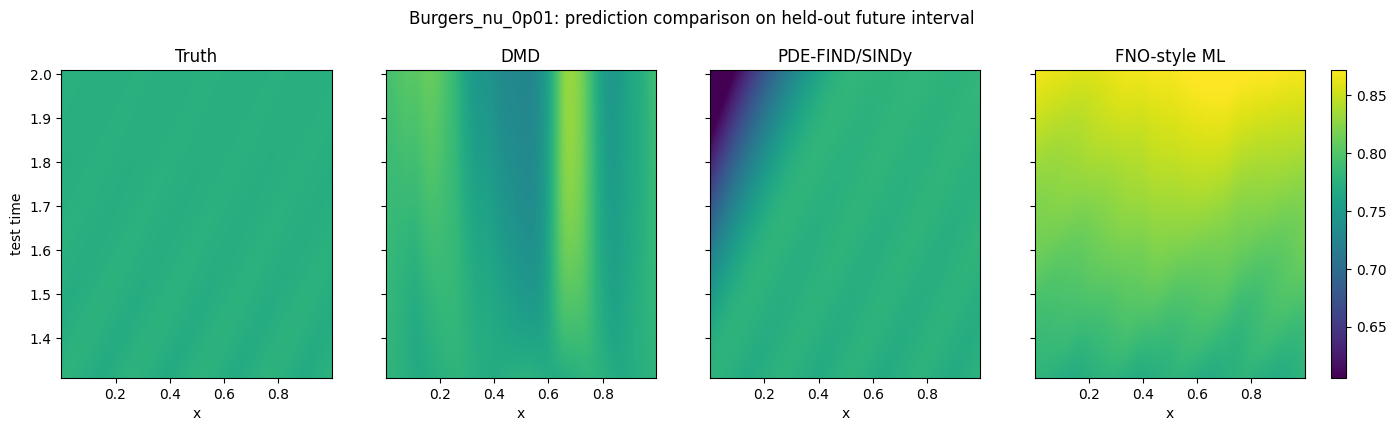

Saved: results/figures/Burgers_nu_0p01_prediction_comparison.png


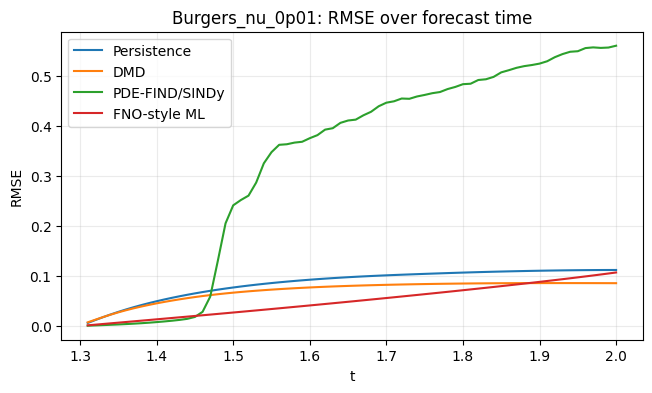

Saved: results/figures/Burgers_nu_0p01_error_over_time.png


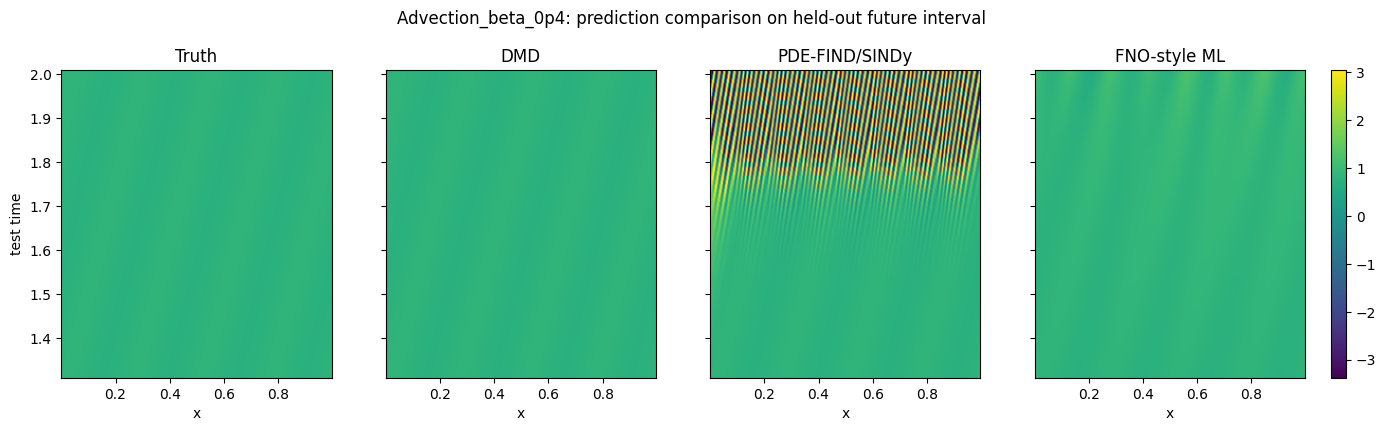

Saved: results/figures/Advection_beta_0p4_prediction_comparison.png


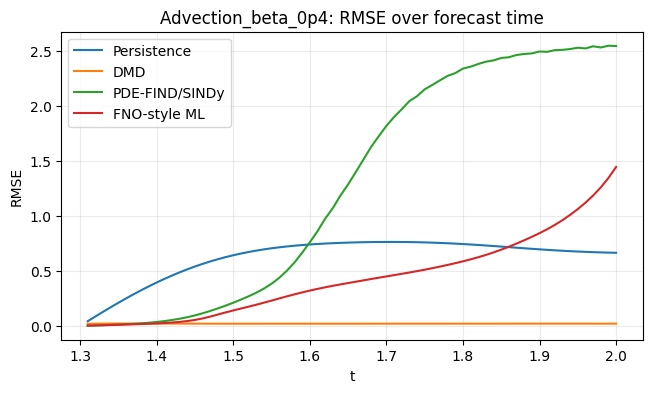

Saved: results/figures/Advection_beta_0p4_error_over_time.png


In [26]:
def plot_prediction_comparison(name: str, ds: dict, sample: int = 0):
    data, x, t = ds["data"], ds["x"], ds["t"]
    n_train = split_train_test(data, CONFIG["train_fraction"])
    true = data[sample, n_train:, :]
    t_test = t[n_train:]

    panels = [("Truth", true)]
    if name in dmd_results:
        panels.append(("DMD", dmd_results[name]["pred"][sample]))
    if name in pdefind_results:
        panels.append(("PDE-FIND/SINDy", pdefind_results[name]["pred"][sample]))
    if name in fno_results:
        panels.append(("FNO-style ML", fno_results[name]["pred"][sample]))

    fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    vmin = min(np.percentile(arr, 1) for _, arr in panels)
    vmax = max(np.percentile(arr, 99) for _, arr in panels)
    for ax, (title, arr) in zip(axes, panels):
        im = ax.imshow(
            arr,
            aspect="auto",
            origin="lower",
            extent=[x[0], x[-1], t_test[0], t_test[-1]],
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("x")
    axes[0].set_ylabel("test time")
    fig.suptitle(f"{name}: prediction comparison on held-out future interval", y=1.03)
    fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    out = FIG_DIR / f"{name}_prediction_comparison.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def plot_error_over_time(name: str, ds: dict):
    data, t = ds["data"], ds["t"]

    # Ensure t has the same length as the data time axis.
    t = t[:data.shape[1]]

    n_train = split_train_test(data, CONFIG["train_fraction"])
    true = data[:, n_train:, :]
    t_test = t[n_train:n_train + true.shape[1]]

    method_preds = {
        "Persistence": persistence_forecast(data, n_train),
    }
    if name in dmd_results:
        method_preds["DMD"] = dmd_results[name]["pred"]
    if name in pdefind_results:
        method_preds["PDE-FIND/SINDy"] = pdefind_results[name]["pred"]
    if name in fno_results:
        method_preds["FNO-style ML"] = fno_results[name]["pred"]

    plt.figure(figsize=(7.5, 4))
    for method, pred in method_preds.items():
        # Align pred and true by the minimum available length.
        m = min(pred.shape[1], true.shape[1], len(t_test))

        pred_m = pred[:, :m, :]
        true_m = true[:, :m, :]
        t_m = t_test[:m]

        rmse_t = np.sqrt(np.mean((pred_m - true_m) ** 2, axis=(0, 2)))
        plt.plot(t_m, rmse_t, label=method)

    plt.title(f"{name}: RMSE over forecast time")
    plt.xlabel("t")
    plt.ylabel("RMSE")
    plt.grid(alpha=0.25)
    plt.legend()
    out = FIG_DIR / f"{name}_error_over_time.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

for name, ds in loaded.items():
    plot_prediction_comparison(name, ds, sample=0)
    plot_error_over_time(name, ds)

## PDE-FIND coefficient interpretation

This section turns the sparse coefficients into a readable statement for the report.

For Burgers, we want the dominant discovered terms to include:

- `u*ux` with coefficient near `-1`;
- `uxx` with coefficient near `nu = 0.01`.

For Advection, we want:

- `ux` with coefficient near `-beta = -0.4`.

Because numerical differentiation is sensitive to grid spacing, downsampling and noise, coefficient values may not be exact. The key question is whether the sparse structure is physically meaningful.

In [27]:
def coefficient_table_for(name: str) -> pd.DataFrame:
    model = pdefind_results[name]["model"]
    df = pd.DataFrame({"term": model["terms"], "coefficient": model["coef"]})
    df["abs_coefficient"] = df["coefficient"].abs()
    return df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)


def interpret_pdefind(name: str, ds: dict) -> str:
    if name not in pdefind_results:
        return f"{name}: PDE-FIND was not run."

    coef_df = coefficient_table_for(name)
    expected = ds["spec"].get("expected", {})
    lines = [f"Dataset: {name} ({ds['spec']['pde']})", "Largest discovered terms:"]
    for _, row in coef_df.head(6).iterrows():
        lines.append(f"  {row['term']:>8s}: {row['coefficient']:+.6g}")
    if expected:
        lines.append("Expected physically important terms:")
        for term, value in expected.items():
            got = coef_df.loc[coef_df["term"] == term, "coefficient"]
            got_value = float(got.iloc[0]) if len(got) else float("nan")
            lines.append(f"  {term:>8s}: expected {value:+.6g}, identified {got_value:+.6g}")
    return "\n".join(lines)


for name, ds in loaded.items():
    print(interpret_pdefind(name, ds))
    print("-" * 80)

coef_exports = []
for name in pdefind_results:
    df = coefficient_table_for(name)
    df.insert(0, "dataset", name)
    coef_exports.append(df)
if coef_exports:
    coef_df_all = pd.concat(coef_exports, ignore_index=True)
    coef_path = RESULTS_DIR / "pdefind_coefficients.csv"
    coef_df_all.to_csv(coef_path, index=False)
    display(coef_df_all)
    print(f"Saved PDE-FIND coefficients: {coef_path}")

Dataset: Burgers_nu_0p01 (Burgers)
Largest discovered terms:
      u*ux: -0.928976
       u^3: +0.109495
         u: -0.0797212
       u^2: +0.0473635
    u^2*ux: -0.0270634
         1: -0.00943841
Expected physically important terms:
      u*ux: expected -1, identified -0.928976
       uxx: expected +0.01, identified +0.00355293
--------------------------------------------------------------------------------
Dataset: Advection_beta_0p4 (Advection)
Largest discovered terms:
        ux: -0.400047
         u: +0.000104256
       u^2: -9.02379e-05
       u^3: -4.4738e-05
    u^2*ux: +1.1412e-05
      u*ux: -8.92756e-06
Expected physically important terms:
        ux: expected -0.4, identified -0.400047
--------------------------------------------------------------------------------


,dataset,term,coefficient,abs_coefficient
0,Burgers_nu_0p01,u*ux,-9.289762e-01,9.289762e-01
1,Burgers_nu_0p01,u^3,1.094950e-01,1.094950e-01
2,Burgers_nu_0p01,u,-7.972124e-02,7.972124e-02
3,Burgers_nu_0p01,u^2,4.736346e-02,4.736346e-02
4,Burgers_nu_0p01,u^2*ux,-2.706339e-02,2.706339e-02
5,Burgers_nu_0p01,1,-9.438409e-03,9.438409e-03
6,Burgers_nu_0p01,ux,8.237217e-03,8.237217e-03
7,Burgers_nu_0p01,uxx,3.552925e-03,3.552925e-03
8,Burgers_nu_0p01,u*uxx,3.591818e-04,3.591818e-04
9,Burgers_nu_0p01,uxxx,1.042286e-06,1.042286e-06


Saved PDE-FIND coefficients: results/pdefind_coefficients.csv


## Automatic conclusion draft

This is not a substitute for human interpretation, but it creates a concise first draft for the presentation and report.

In [28]:
summary_lines = []
summary_lines.append("# Project 12 summary")
summary_lines.append("")
summary_lines.append("## Datasets")
for name, ds in loaded.items():
    summary_lines.append(
        f"- {name}: original shape {ds['shape_original']}, loaded subset {ds['shape_loaded']}."
    )

summary_lines.append("")
summary_lines.append("## Metrics")
summary_lines.append("```")
summary_lines.append(metrics_df.to_string(index=False))
summary_lines.append("```")

summary_lines.append("")
summary_lines.append("## Best method by nRMSE")
for dataset, group in metrics_df.groupby("dataset"):
    best = group.sort_values("nRMSE").iloc[0]
    summary_lines.append(
        f"- {dataset}: best method is {best['method']} with nRMSE={best['nRMSE']:.4g}, RMSE={best['RMSE']:.4g}."
    )

summary_lines.append("")
summary_lines.append("## PDE-FIND interpretation")
for name, ds in loaded.items():
    summary_lines.append("```")
    summary_lines.append(interpret_pdefind(name, ds))
    summary_lines.append("```")

summary_lines.append("")
summary_lines.append("## Suggested final conclusion")
summary_lines.append(
    "DMD gives a fast modal baseline for short-horizon prediction. PDE-FIND/SINDy gives interpretable sparse equations and can recover physically meaningful terms, but it is sensitive to numerical derivatives and rollout stability. The FNO-style neural baseline is less interpretable but usually provides a strong accuracy baseline even in this compact local setup. The final comparison should discuss the accuracy-versus-interpretability tradeoff and the computational cost of each method."
)

summary_text = "\n".join(summary_lines)
summary_path = RESULTS_DIR / "final_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")
print(summary_text[:4000])
print(f"\nSaved summary: {summary_path}")

# Project 12 summary

## Datasets
- Burgers_nu_0p01: original shape (10000, 201, 1024), loaded subset (64, 201, 256).
- Advection_beta_0p4: original shape (10000, 201, 1024), loaded subset (64, 201, 256).

## Metrics
```
           dataset       pde         method  train_seconds  prediction_seconds  total_seconds     RMSE    nRMSE      MAE     MAPE_eps  max_error  boundary_RMSE  conserved_RMSE  fourier_low  fourier_mid  fourier_high
Advection_beta_0p4 Advection            DMD       0.393660            0.083092       0.476752 0.021106 0.030029 0.006632 1.576315e+05   0.550026       0.010387        0.000042     0.023707     1.000880  1.000033e+00
Advection_beta_0p4 Advection   FNO-style ML      18.350552            0.159864      18.510416 0.573843 0.816466 0.261692 1.451790e+06  24.916783       0.585650        0.221268     0.697358    15.862854  1.710509e+01
Advection_beta_0p4 Advection    Persistence       0.000000            0.000000       0.000000 0.654168 0.930754 0.451053 9.279989e+

## Final artifacts

After running the notebook, use these files from the project `results/` directory:

- `metrics_table.csv`: final method comparison table;
- `pdefind_coefficients.csv`: identified PDE coefficients;
- `final_summary.md`: short report draft;
- `figures/*_overview.png`: data visualizations;
- `figures/*_prediction_comparison.png`: truth vs predictions;
- `figures/*_error_over_time.png`: forecast error curves;
- `figures/*_fno_loss.png`: neural baseline training curves.

Recommended slide structure:

1. Problem and PDEBench data.
2. Data parsing and visualization.
3. DMD method and prediction result.
4. PDE-FIND/SINDy method and identified coefficients.
5. FNO-style ML baseline.
6. Metrics table and runtime comparison.
7. Interpretation: accuracy, interpretability, limitations, next improvements.